# Zadanie 1
## Klasyfikacja Absorbcja/Dystrybucja

| Task | Description |
|------|-------------|
| hia_hou | Absorption |
| bioavailability_ma | Absorption |
| bbb_martins | Distribution |

Brak wspólnych smiles bbb_martins i hia_hou

### Analiza statystyczna


In [2]:
import pandas as pd
from os import getcwd
import seaborn as sns
import matplotlib.pyplot as plt

import random_forest_model
# print(getcwd())

df = pd.read_parquet('./../../../dataset.parquet')
tasks = ['bioavailability_ma', 'hia_hou', 'pgp_broccatelli', 'bbb_martins',
 'cyp2c9_veith', 'cyp2d6_veith', 'cyp3a4_veith',
 'cyp2c9_substrate_carbonmangels', 'cyp2d6_substrate_carbonmangels',
 'cyp3a4_substrate_carbonmangels', 'hERG_Karim' 'ames' 'dili']

df = df[df['task'].isin(tasks)]

df_wide = df.pivot_table(index='smiles', columns='task', values='label')

In [3]:
print(df['task'].value_counts())
avg_tasks = df.groupby('smiles')['task'].nunique().mean()
print(f"Średnia liczba zadań na smiles: {avg_tasks:.2f}")
presence_mask = df_wide.notna().astype(int)

overlap_matrix = presence_mask.T @ presence_mask

stats_df = df.groupby('task')['label'].agg(['mean', 'count', 'std']).reset_index()
overlap_matrix = overlap_matrix.merge(stats_df, on='task')
overlap_matrix.head()

task
cyp2d6_veith                      13130
cyp3a4_veith                      12328
cyp2c9_veith                      12092
bbb_martins                        2030
pgp_broccatelli                    1218
cyp3a4_substrate_carbonmangels      670
cyp2c9_substrate_carbonmangels      669
cyp2d6_substrate_carbonmangels      667
bioavailability_ma                  640
hia_hou                             578
Name: count, dtype: int64
Średnia liczba zadań na smiles: 2.22


,task,bbb_martins,bioavailability_ma,cyp2c9_substrate_carbonmangels,cyp2c9_veith,cyp2d6_substrate_carbonmangels,cyp2d6_veith,cyp3a4_substrate_carbonmangels,cyp3a4_veith,hia_hou,pgp_broccatelli,mean,count,std
0,bbb_martins,1975,293,216,114,217,114,216,104,90,111,0.764039,2030,0.424702
1,bioavailability_ma,293,640,203,81,204,92,202,85,129,93,0.768750,640,0.421962
2,cyp2c9_substrate_carbonmangels,216,203,666,113,660,112,661,103,127,112,0.210762,669,0.408155
3,cyp2c9_veith,114,81,113,12092,113,9750,114,9265,91,134,0.334519,12092,0.471841
4,cyp2d6_substrate_carbonmangels,217,204,660,113,664,112,658,102,130,111,0.286357,667,0.452397


In [4]:
mask = df.groupby('smiles')['task'].transform('nunique') > 1
duplicated_rows = df[df.groupby('smiles')['task'].transform('nunique') > 1].sort_values('smiles')

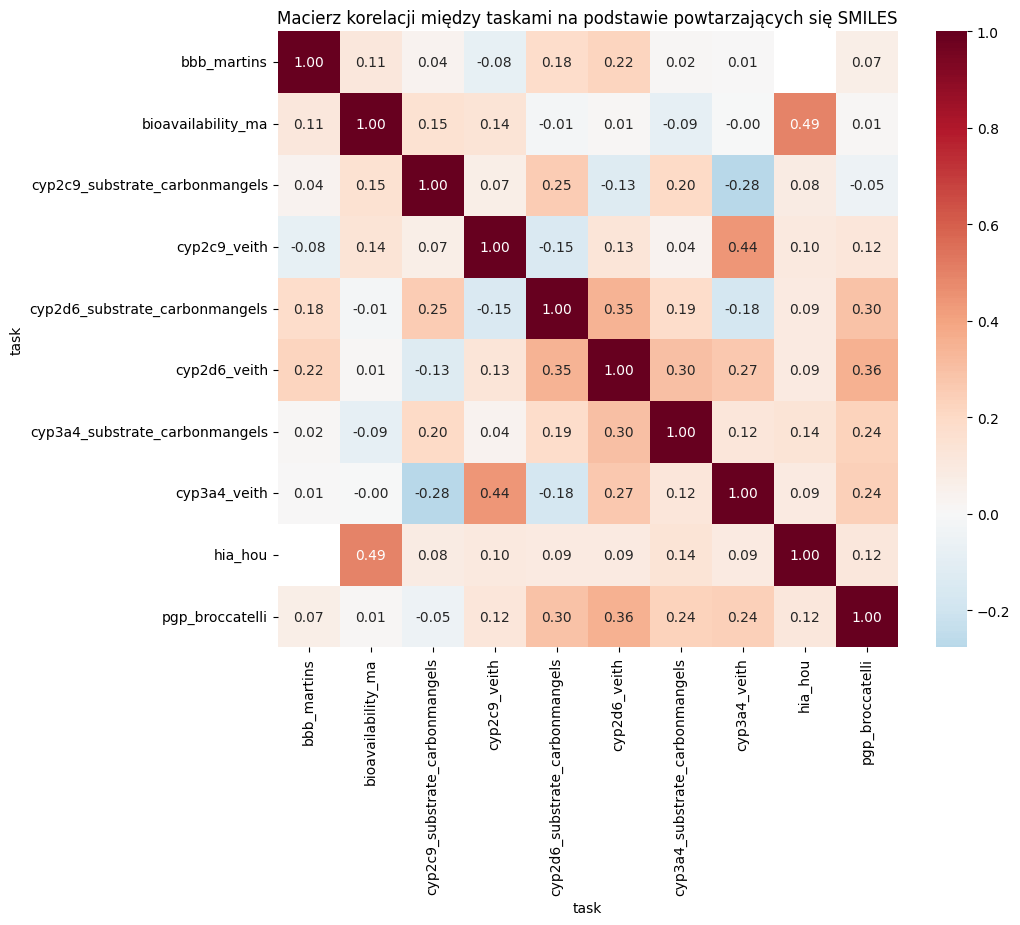

In [5]:
corr_matrix = df_wide.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, fmt=".2f")
plt.title('Macierz korelacji między taskami na podstawie powtarzających się SMILES')
plt.show()

NaN wynika z braku wariancji w części wspólnej hia_hou (absorbcja) i bbb_martins (dystrybucja). W każdym przypadku jeśli badano oba związki to absorbcja wynosiła True.

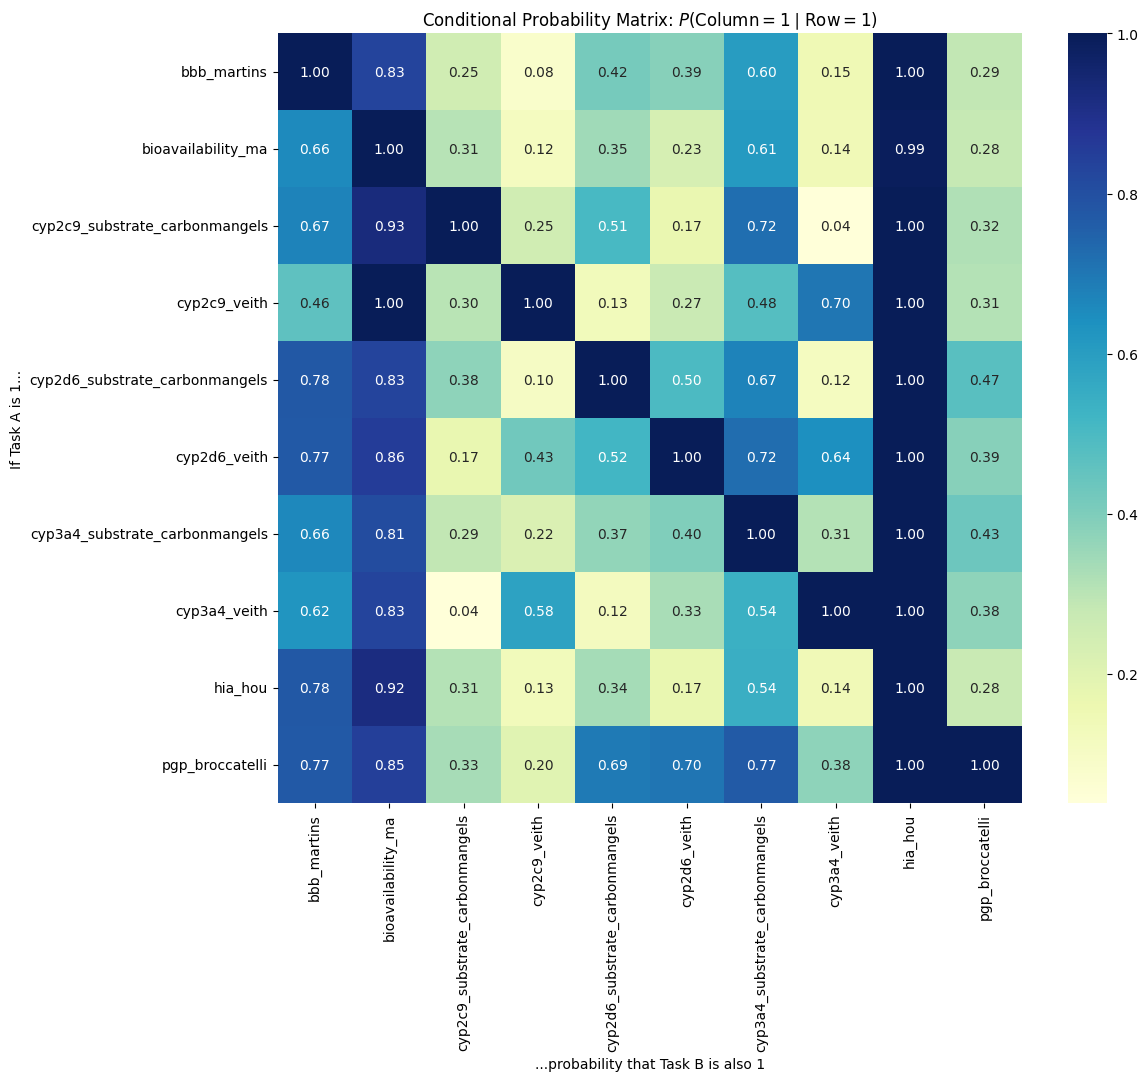

In [6]:
ones_mask = (df_wide == 1).astype(int)
intersection_11 = ones_mask.T @ ones_mask

valid_mask = df_wide.notna().astype(int)
intersection_1x = ones_mask.T @ valid_mask

cond_prob = intersection_11 / intersection_1x

plt.figure(figsize=(12, 10))
sns.heatmap(cond_prob, annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Conditional Probability Matrix: $P(\\text{Column}=1 \\mid \\text{Row}=1)$")
plt.ylabel("If Task A is 1...")
plt.xlabel("...probability that Task B is also 1")
plt.show()

### Random Forest

In [7]:
summary_df = random_forest_model.run_single_task_pipeline(df, tasks)
# summary_df['SOTA'] = ['0.989±0.001', '0.748±0.033', '0.916±0.001']
# summary_df['MTL auc'] = [' 0.8835', '0.6722', '0.9759']

# bbb_martins: 0.8835
# bioavailability_ma: 0.6722
# hia_hou: 0.9759
summary_df


--- Top 15 najważniejszych cech dla bioavailability_ma ---
            feature  importance
                qed    0.023362
               TPSA    0.021596
NumValenceElectrons    0.020476
              MolMR    0.019032
          LabuteASA    0.018737
              MolWt    0.017683
   MaxPartialCharge    0.016987
            MolLogP    0.016804
         NumHDonors    0.014577
MaxAbsPartialCharge    0.013753
           BalabanJ    0.013733
     HeavyAtomCount    0.013284
       FractionCSP3    0.012107
            NOCount    0.010613
          NHOHCount    0.010451

--- Top 15 najważniejszych cech dla hia_hou ---
            feature  importance
                qed    0.050851
               TPSA    0.048510
            NOCount    0.031310
          NHOHCount    0.028523
            MolLogP    0.027936
         NumHDonors    0.027043
              MolWt    0.024547
      NumHAcceptors    0.024187
           BalabanJ    0.020982
          LabuteASA    0.020573
              MolMR    0.02

,task,auc,acc,f1
0,bioavailability_ma,0.687865,0.726562,0.834123
1,hia_hou,0.946555,0.905172,0.946341
2,pgp_broccatelli,0.932104,0.868852,0.866667
3,bbb_martins,0.904258,0.864532,0.914463
4,cyp2c9_veith,0.896691,0.817204,0.708827
5,cyp2d6_veith,0.873928,0.872430,0.537931
6,cyp3a4_veith,0.885595,0.797242,0.740933
7,cyp2c9_substrate_carbonmangels,0.671166,0.798507,0.000000
8,cyp2d6_substrate_carbonmangels,0.721695,0.751880,0.400000
9,cyp3a4_substrate_carbonmangels,0.626643,0.589552,0.635762



SOTA results from paper "Quantum Enhanced MTL ...".


In our model used RandomForestClassifier from scikit with 200 estimators.

### MTL model

Start treningu na cuda. Ilość cech: 1066, Ilość zadań: 10
Epoch 00 | Train Loss: 0.4745 | Val Loss: 0.4034 | Avg Val AUC: 0.7703
Epoch 01 | Train Loss: 0.3770 | Val Loss: 0.3886 | Avg Val AUC: 0.7973
Epoch 02 | Train Loss: 0.3349 | Val Loss: 0.3740 | Avg Val AUC: 0.8035
Epoch 03 | Train Loss: 0.3096 | Val Loss: 0.3720 | Avg Val AUC: 0.8170
Epoch 04 | Train Loss: 0.2822 | Val Loss: 0.3695 | Avg Val AUC: 0.8230
Epoch 05 | Train Loss: 0.2551 | Val Loss: 0.3829 | Avg Val AUC: 0.8283
Epoch 06 | Train Loss: 0.2325 | Val Loss: 0.4045 | Avg Val AUC: 0.8271
Epoch 07 | Train Loss: 0.2100 | Val Loss: 0.4047 | Avg Val AUC: 0.8358
Epoch 08 | Train Loss: 0.1911 | Val Loss: 0.4170 | Avg Val AUC: 0.8227
Epoch 09 | Train Loss: 0.1751 | Val Loss: 0.4358 | Avg Val AUC: 0.8278
Epoch 10 | Train Loss: 0.1645 | Val Loss: 0.4519 | Avg Val AUC: 0.8300
Epoch 11 | Train Loss: 0.1465 | Val Loss: 0.4619 | Avg Val AUC: 0.8334
Epoch 12 | Train Loss: 0.1308 | Val Loss: 0.4834 | Avg Val AUC: 0.8315
Epoch 13 | Train Lo

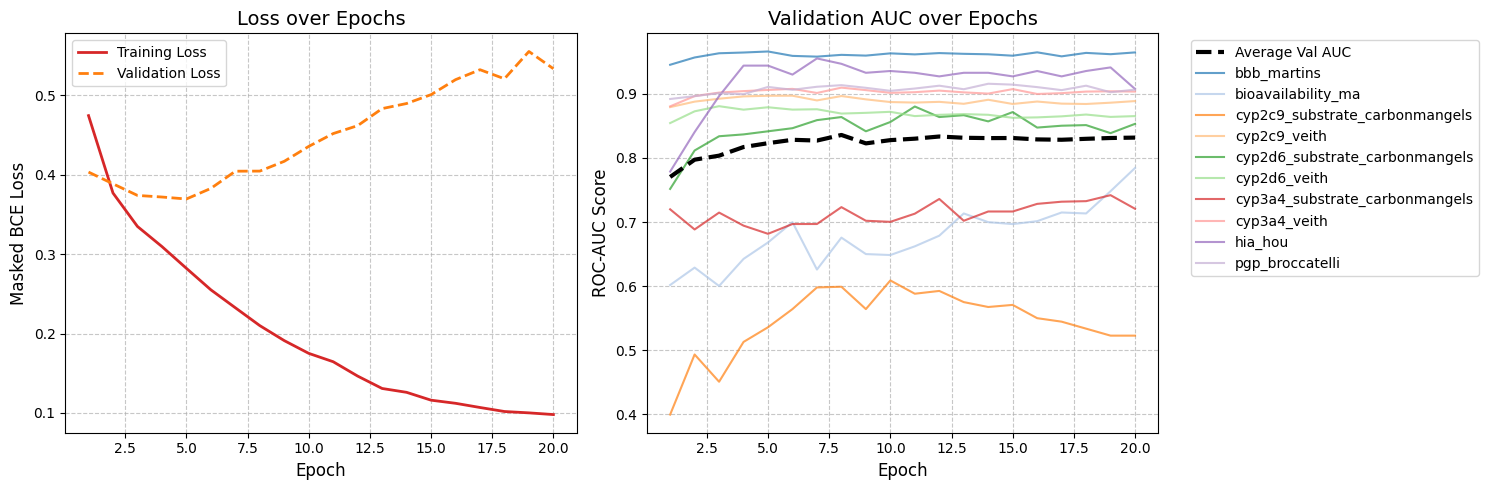


--- FINAL TEST AUC ---
bbb_martins: 0.8982
bioavailability_ma: 0.7336
cyp2c9_substrate_carbonmangels: 0.6796
cyp2c9_veith: 0.8868
cyp2d6_substrate_carbonmangels: 0.7078
cyp2d6_veith: 0.8551
cyp3a4_substrate_carbonmangels: 0.6603
cyp3a4_veith: 0.8949
hia_hou: 0.9709
pgp_broccatelli: 0.9356

--- FEATURE IMPORTANCE ---
            feature  importance
                qed    0.015851
             fr_C_O    0.015802
       fr_sulfonamd    0.010150
           fr_ester    0.008290
             fr_NH0    0.006705
MinAbsPartialCharge    0.006029
           fr_Al_OH    0.005865
            bit_650    0.005545
           fr_Ar_NH    0.005114
            bit_573    0.004822
         NumHDonors    0.004811
             dipole    0.004787
         fr_benzene    0.004447
     HeavyAtomCount    0.003769
             bit_64    0.003644
            bit_753    0.003496
            bit_956    0.003471
            bit_548    0.003407
            bit_561    0.003401
            bit_881    0.003373
         

In [8]:
%load_ext autoreload
%autoreload 2

import torch
import numpy as np
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

from mtl_utils import (
    prepare_mtl_data, MTLDataset, MTLNet,
    train_epoch, evaluate, permutation_importance_mtl
)

X_all, y_all, mask_all, tasks, splits, feat_names = prepare_mtl_data(df)

train_idx = splits == 'train'
val_idx = splits == 'valid'
test_idx = splits == 'test'

train_loader = DataLoader(MTLDataset(X_all[train_idx], y_all[train_idx], mask_all[train_idx]), batch_size=128, shuffle=True)
val_loader = DataLoader(MTLDataset(X_all[val_idx], y_all[val_idx], mask_all[val_idx]), batch_size=128)
test_loader = DataLoader(MTLDataset(X_all[test_idx], y_all[test_idx], mask_all[test_idx]), batch_size=128)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = MTLNet(X_all.shape[1], len(tasks)).to(device)
opt = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

print(f"Start treningu na {device}. Ilość cech: {X_all.shape[1]}, Ilość zadań: {len(tasks)}")

# Słownik wzbogacony o val_loss
history = {'loss': [], 'val_loss': [], 'val_aucs': []}

for epoch in range(20):
    train_loss = train_epoch(model, train_loader, opt, device)

    # Odbieramy teraz też val_loss
    val_loss, val_aucs = evaluate(model, val_loader, device, tasks)

    # Zapisujemy do historii
    history['loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_aucs'].append(val_aucs)

    avg_val_auc = np.nanmean(list(val_aucs.values()))
    print(f"Epoch {epoch:02d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Avg Val AUC: {avg_val_auc:.4f}")


# --- FUNKCJA DO WYKRESÓW ---
def plot_training_history(history, tasks):
    epochs = range(1, len(history['loss']) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # --- Wykres 1: Training vs Validation Loss ---
    ax1.plot(epochs, history['loss'], color='tab:red', label='Training Loss', linewidth=2)
    ax1.plot(epochs, history['val_loss'], color='tab:orange', label='Validation Loss', linewidth=2, linestyle='--')

    ax1.set_title('Loss over Epochs', fontsize=14)
    ax1.set_xlabel('Epoch', fontsize=12)
    ax1.set_ylabel('Masked BCE Loss', fontsize=12)
    ax1.grid(True, linestyle='--', alpha=0.7)
    ax1.legend()

    # --- Wykres 2: Validation AUC ---
    avg_aucs = [np.nanmean(list(epoch_aucs.values())) for epoch_aucs in history['val_aucs']]
    ax2.plot(epochs, avg_aucs, 'k--', label='Average Val AUC', linewidth=3, zorder=10)

    cmap = plt.get_cmap('tab20')
    for i, task in enumerate(tasks):
        task_aucs = [epoch_aucs[task] for epoch_aucs in history['val_aucs']]
        ax2.plot(epochs, task_aucs, label=task, color=cmap(i), alpha=0.7, linewidth=1.5)

    ax2.set_title('Validation AUC over Epochs', fontsize=14)
    ax2.set_xlabel('Epoch', fontsize=12)
    ax2.set_ylabel('ROC-AUC Score', fontsize=12)
    ax2.grid(True, linestyle='--', alpha=0.7)
    ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.tight_layout()
    plt.show()

# --- WYZWALAMY WYKRES I TEST KOŃCOWY ---
plot_training_history(history, tasks)

test_loss, test_aucs = evaluate(model, test_loader, device, tasks)
print("\n--- FINAL TEST AUC ---")
for t, v in test_aucs.items():
    print(f"{t}: {v:.4f}")

print("\n--- FEATURE IMPORTANCE ---")
imp_df = permutation_importance_mtl(model, test_loader, device, feat_names)
print(imp_df.head(25).to_string(index=False))